=== Unmatched files (category could not be determined) ===


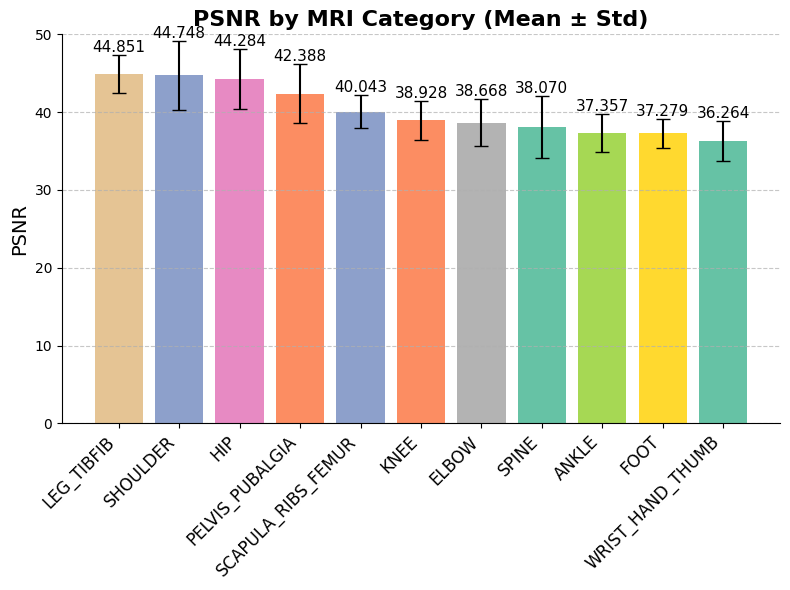

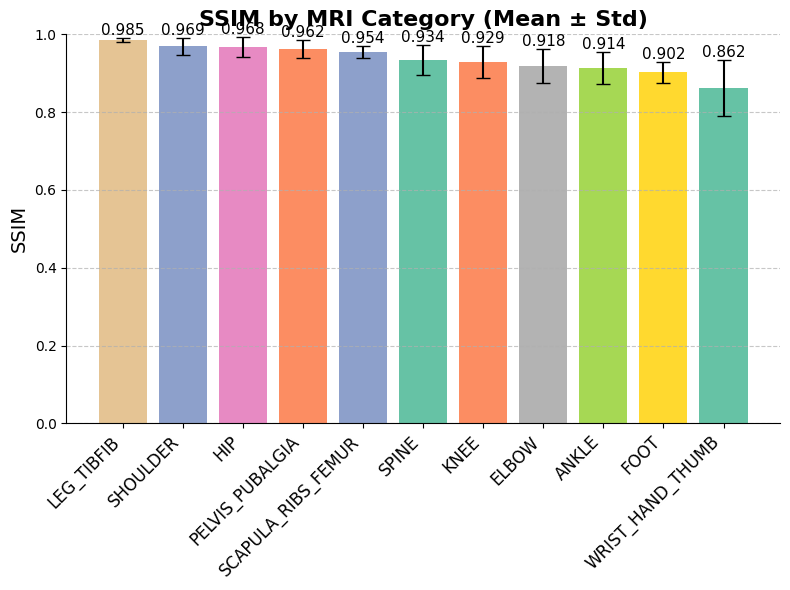

Global average PSNR: 40.00
Global average SSIM: 0.9410


In [ ]:
import os, json, h5py, xml.dom.minidom as minidom
from collections import defaultdict, Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- CONFIG: set these ----------
results_path = "../outputs/january_exps/test_on_msk/varnet_mskmrpro_FULL_casc8_acc8"
json_path = results_path + "/metrics.json"   # path to your JSON above
data_dir  = "../../../../../data/datasets/msk_mri_h5/varnet_msk_dataset2/multicoil_test"  # folder containing the .h5 files
# --------------------------------------

scan_categories = {
    "SPINE": {"includes": ["L-SPINE","LSPINE","L SPINE","C-SPINE","CSPINE","C SPINE","T-SPINE","T SPINE",
                           "AX T2 T-SP","AX T2 T-SP WARP"]},
    "KNEE": {"includes": ["LT KNEE","RT KNEE"]},
    "SHOULDER": {"includes": ["LT SHOULDER","RT SHOULDER"]},
    "HIP": {"includes": ["LT HIP","RT HIP"]},
    "ANKLE": {"includes": ["LT ANKLE","RT ANKLE"]},
    "FOOT": {"includes": ["LT FOOT","RT FOOT"]},
    "LEG_TIBFIB": {"includes": ["LT LEG","RT TIB-FIB"]},
    "ELBOW": {"includes": ["LT ELBOW","RT ELBOW"]},
    "WRIST_HAND_THUMB": {"includes": ["LT WRIST","RT WRIST","LT THUMB","RT THUMB","RT HAND","WRIST RT"]},
    "PELVIS_PUBALGIA": {"includes": ["PELVIS","ATH PUBALGIA"]},
    "SCAPULA_RIBS_FEMUR": {"includes": ["RT SCAPULA","RIBS","LT FEMUR"]},
}

def parse_header_study_and_patient(h5_path):
    """Return (tStudyDescription, patientID) from ismrmrd_header; None if missing."""
    try:
        with h5py.File(h5_path, "r") as f:
            if "ismrmrd_header" not in f:
                return None, None
            xml_raw = f["ismrmrd_header"][()]
            if isinstance(xml_raw, (bytes, bytearray, np.void)):
                xml_str = bytes(xml_raw).decode(errors="ignore")
            else:
                xml_str = str(xml_raw)
        dom = minidom.parseString(xml_str)
        # generic helper
        def _first_text(parent, tag):
            nodes = parent.getElementsByTagName(tag)
            if nodes and nodes[0].firstChild:
                return nodes[0].firstChild.data.strip()
            return None

        # userParameters may have name/value pairs
        study = None
        ups = dom.getElementsByTagName("userParameterString")
        for node in ups:
            name = _first_text(node, "name")
            if name == "tStudyDescription":
                study = _first_text(node, "value")
                break

        # fallback: try studyInformation/studyDescription (not always present)
        if study is None:
            study = _first_text(dom, "studyDescription")

        # patientID (typical location: subjectInformation/patientID)
        pid = None
        sub = dom.getElementsByTagName("subjectInformation")
        if sub:
            pid = _first_text(sub[0], "patientID")

        return study, pid
    except Exception:
        return None, None

def categorize(study_desc):
    if not study_desc:
        return None
    s = study_desc.upper()
    for cat, info in scan_categories.items():
        for token in info["includes"]:
            if token in s:
                return cat
    return None

# --------- Load JSON ----------
with open(json_path, "r") as f:
    metrics_json = json.load(f)

per_vol = metrics_json.get("per_volume", {})
global_psnr = metrics_json.get("global", {}).get("PSNR").get("mean")
global_ssim = metrics_json.get("global", {}).get("SSIM").get("mean")

# --------- Build table ----------
rows = []
unmatched = []
for fname, m in per_vol.items():
    h5_path = os.path.join(data_dir, fname)
    study, pid = parse_header_study_and_patient(h5_path)
    cat = categorize(study)
    if cat is None:
        unmatched.append((fname, study))
    rows.append({
        "file": fname,
        "category": cat,
        "study": study,
        "patientID": pid,
        "PSNR": m.get("PSNR"),
        "SSIM": m.get("SSIM"),
    })

df = pd.DataFrame(rows)

# --------- Print unmatched and patient counts ----------
print("=== Unmatched files (category could not be determined) ===")
for fname, study in unmatched:
    print(f"- {fname} | tStudyDescription={study}")

df_matched = df.dropna(subset=["category"])
# --------- Plots: one figure per metric (bar of mean with std) ----------
import matplotlib.pyplot as plt

# Assign a color to each category for consistent plotting
# Assign a color to each possible category for consistent plotting
all_categories = list(scan_categories.keys())
color_list = plt.cm.Set2.colors
color_map = {cat: color_list[i % len(color_list)] for i, cat in enumerate(all_categories)}

def plot_metric(metric_name):
    g = df_matched.groupby("category")[metric_name]
    means = g.mean().sort_values(ascending=False)
    stds  = g.std().reindex(means.index)

    # Get colors for each category in the order of means.index, fallback to a default if missing
    default_color = "gray"
    bar_colors = [color_map.get(cat, default_color) for cat in means.index]


    plt.figure(figsize=(8, 6))
    bars = plt.bar(range(len(means)), means.values, yerr=stds.values, capsize=5, 
                   color=bar_colors)

    plt.xticks(range(len(means)), means.index, rotation=45, ha='right', fontsize=12)
    plt.ylabel(metric_name, fontsize=14)
    plt.title(f"{metric_name} by MRI Category (Mean ± Std)", fontsize=16, weight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.gca().set_facecolor('white')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.ylim(0, 50.0 if metric_name == "PSNR" else 1.0)

    # Add value labels on top of bars
    for bar, mean, std in zip(bars, means.values, stds.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std, 
                 f"{mean:.3f}", ha='center', va='bottom', fontsize=11)

    plt.tight_layout()

for metric in ["PSNR", "SSIM"]:
    plot_metric(metric)

plt.show()

print(f'Global average PSNR: {global_psnr:.2f}')
print(f'Global average SSIM: {global_ssim:.4f}')


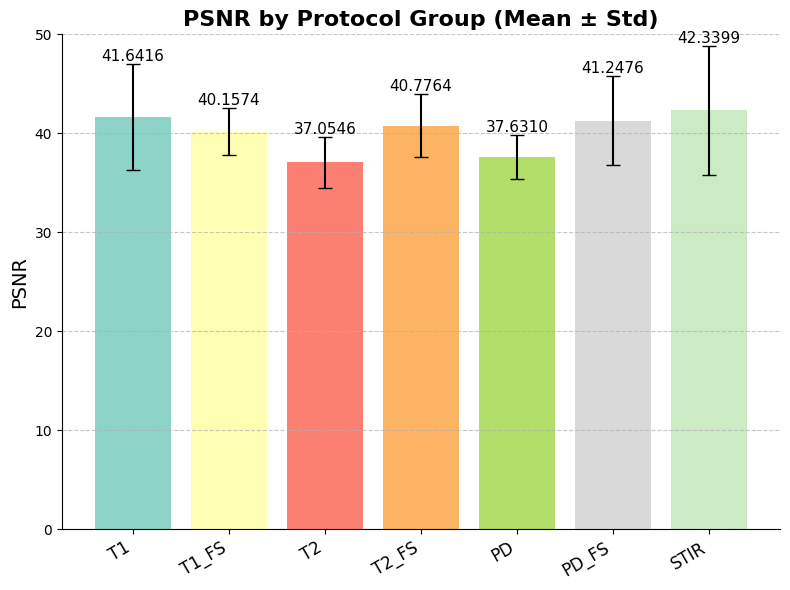

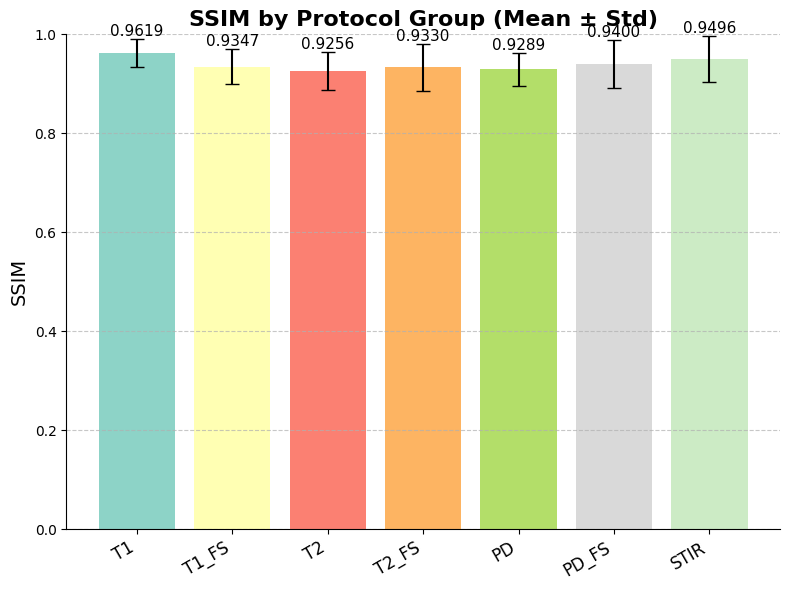

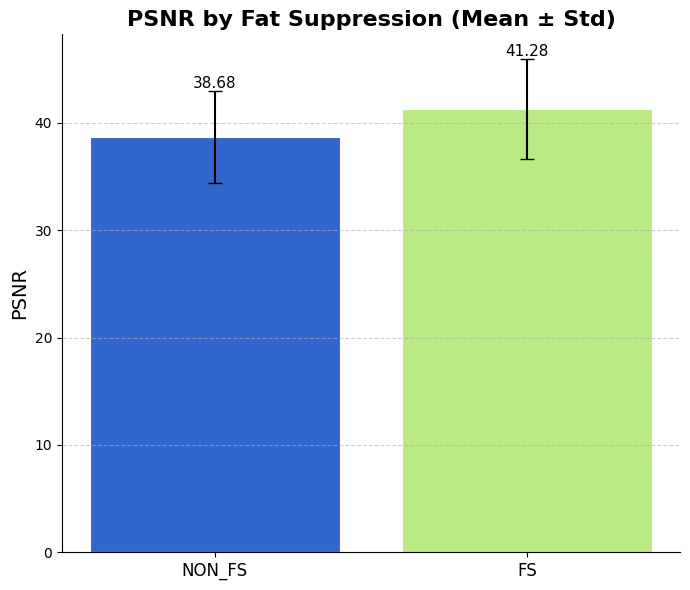

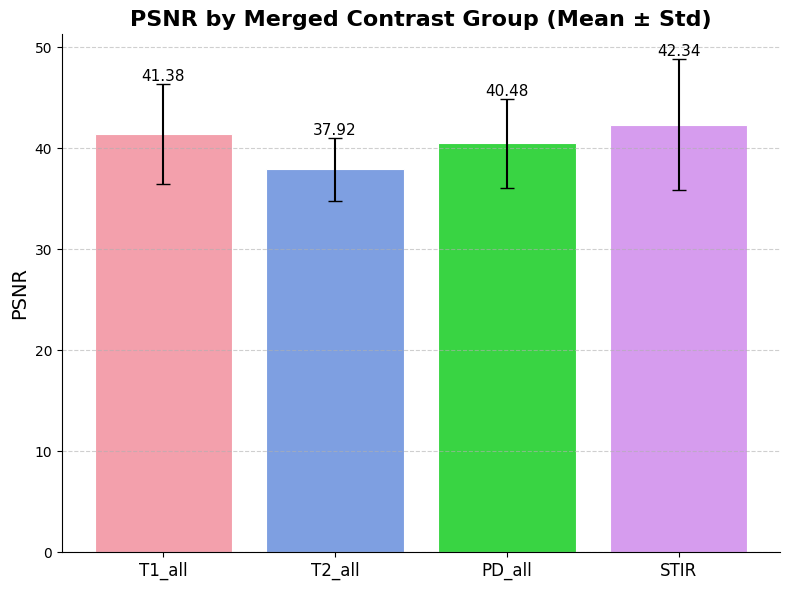

In [2]:
# --------- Plot metrics by 6 protocol groups (T1, T1_FS, T2, T2_FS, PD, PD_FS) ----------
import xml.dom.minidom as _minidom
import numpy as np
import matplotlib.pyplot as plt
# Parse tProtocolName from ismrmrd_header
def parse_header_protocol(h5_path):
    try:
        with h5py.File(h5_path, "r") as f:
            if "ismrmrd_header" not in f:
                return None
            xml_raw = f["ismrmrd_header"][()]
            if isinstance(xml_raw, (bytes, bytearray, np.void)):
                xml_str = bytes(xml_raw).decode(errors="ignore")
            else:
                xml_str = str(xml_raw)
        dom = _minidom.parseString(xml_str)
        def _first_text(parent, tag):
            nodes = parent.getElementsByTagName(tag)
            if nodes and nodes[0].firstChild:
                return nodes[0].firstChild.data.strip()
            return None
        ups = dom.getElementsByTagName("userParameterString")
        for node in ups:
            name = _first_text(node, "name")
            if name == "tProtocolName":
                return _first_text(node, "value")
        return None
    except Exception:
        return None

# Map raw protocol to one of six protocol groups
def get_contrast_group(proto: str) -> str:
    """
    Map a raw tProtocolName string to a *merged* contrast/sequence group.

    Final groups:
        - T1       = T1, T1_PRE, T1_POST (no FS)
        - T1_FS    = T1_FS, T1_FS_POST
        - T2       = plain T2
        - T2_FS    = T2_FS, T2_FS_DIXON (any T2 with FS or DIXON)
        - PD       = plain PD
        - PD_FS    = PD_FS, PD_FS_DIXON (any PD with FS or DIXON)
        - STIR     = any STIR sequence
    """
    name = proto.upper()

    if "STIR" in name:
        return "STIR"

    base = None
    if "PD" in name:
        base = "PD"
    elif "T2" in name:
        base = "T2"
    elif "T1" in name:
        base = "T1"
    else:
        return "OTHER"

    has_fs = "FS" in name
    has_dixon = "DIXON" in name

    if base == "T1":
        if has_fs or has_dixon:
            return "T1_FS"
        return "T1"

    if base == "T2":
        if has_fs or has_dixon:
            return "T2_FS"
        return "T2"

    if base == "PD":
        if has_fs or has_dixon:
            return "PD_FS"
        return "PD"

    return "OTHER"

# Build DataFrame with protocol groups
proto_rows = []
for fname, m in per_vol.items():
    h5_path = os.path.join(data_dir, fname)
    pg = get_contrast_group(parse_header_protocol(h5_path))
    if pg is None:
        continue
    proto_rows.append({
        "file": fname,
        "protocol_group": pg,
        "PSNR": m.get("PSNR"),
        "SSIM": m.get("SSIM"),
    })

df_proto = pd.DataFrame(proto_rows)

# Plot helper similar to category plots
def plot_metric_by_protocol(metric_name):
    if df_proto.empty:
        print("No protocol group data available to plot.")
        return
    proto_order = ["T1", "T1_FS", "T2", "T2_FS", "PD", "PD_FS", "STIR"]
    g = df_proto.groupby("protocol_group")[metric_name]
    means = g.mean().reindex(proto_order).dropna()
    stds  = g.std().reindex(means.index)

    # Colors per protocol group
    cmap = plt.cm.Set3
    colors = [cmap(i / max(1, len(proto_order))) for i in range(len(proto_order))]
    bar_colors = [colors[proto_order.index(p)] if p in proto_order else "gray" for p in means.index]

    plt.figure(figsize=(8, 6))
    bars = plt.bar(range(len(means)), means.values, yerr=stds.values, capsize=5, color=bar_colors)
    plt.xticks(range(len(means)), means.index, rotation=30, ha='right', fontsize=12)
    plt.ylabel(metric_name, fontsize=14)
    plt.title(f"{metric_name} by Protocol Group (Mean ± Std)", fontsize=16, weight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.gca().set_facecolor('white')
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.ylim(0, 50.0 if metric_name == "PSNR" else 1.0)

    for bar, mean, std in zip(bars, means.values, stds.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (std if not np.isnan(std) else 0),
                 f"{mean:.4f}", ha='center', va='bottom', fontsize=11)
    plt.tight_layout()

# Generate protocol plots
for metric in ["PSNR", "SSIM"]:
    plot_metric_by_protocol(metric)
plt.show()


# Academic-but-fun palette (consistent with earlier work)
PRO_COLORS = {
    'NON_FS': '#3366CC',
    'FS': "#BBE983",
    'T1_all': "#F3A0AC",
    'T2_all': "#7E9FE1",
    'PD_all': "#39D443",
    'STIR': "#D69CEE",
}

# Build per-file protocol string if needed and compute FS label and merged contrast group
fs_rows = []
merged_rows = []
for fname, m in per_vol.items():
    h5_path = os.path.join(data_dir, fname)
    proto = parse_header_protocol(h5_path)
    if proto is None:
        continue
    psnr = m.get('PSNR')
    if psnr is None or np.isnan(psnr):
        continue

    name = proto.upper()
    is_fs = ('FS' in name) or ('DIXON' in name) or ('STIR' in name)
    fs_rows.append({
        'file': fname,
        'FS_flag': 'FS' if is_fs else 'NON_FS',
        'PSNR': psnr,
    })

    cg = get_contrast_group(proto)
    if cg == 'OTHER':
        continue
    if cg == 'STIR':
        merged = 'STIR'
    elif cg.startswith('T1'):
        merged = 'T1_all'
    elif cg.startswith('T2'):
        merged = 'T2_all'
    elif cg.startswith('PD'):
        merged = 'PD_all'
    else:
        continue
    merged_rows.append({
        'file': fname,
        'merged_group': merged,
        'PSNR': psnr,
    })

import pandas as pd

df_fs = pd.DataFrame(fs_rows)
df_merged = pd.DataFrame(merged_rows)

# --- Plot: PSNR on Non-FS vs FS ---
if df_fs.empty:
    print('No data available for FS vs Non-FS PSNR plot.')
else:
    order = ['NON_FS', 'FS']
    g = df_fs.groupby('FS_flag')['PSNR']
    means = g.mean().reindex(order).dropna()
    stds = g.std().reindex(means.index)

    plt.figure(figsize=(7, 6))
    colors = [PRO_COLORS.get(lbl, '#777777') for lbl in means.index]
    bars = plt.bar(range(len(means)), means.values, yerr=stds.values, capsize=5, color=colors, edgecolor='white', linewidth=0.8)
    plt.xticks(range(len(means)), means.index, fontsize=12)
    plt.ylabel('PSNR', fontsize=14)
    plt.title('PSNR by Fat Suppression (Mean ± Std)', fontsize=16, weight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    for bar, mean, std in zip(bars, means.values, stds.values):
        y = bar.get_height()
        off = 0 if np.isnan(std) else std
        plt.text(bar.get_x() + bar.get_width()/2, y + off, f"{mean:.2f}", ha='center', va='bottom', fontsize=11)
    plt.tight_layout()
    plt.show()

# --- Plot: PSNR on merged contrasts (T1_all, T2_all, PD_all, STIR) ---
if df_merged.empty:
    print('No data available for merged contrast PSNR plot.')
else:
    order = ['T1_all', 'T2_all', 'PD_all', 'STIR']
    g = df_merged.groupby('merged_group')['PSNR']
    means = g.mean().reindex(order).dropna()
    stds  = g.std().reindex(means.index)

    plt.figure(figsize=(8, 6))
    colors = [PRO_COLORS.get(lbl, '#777777') for lbl in means.index]
    bars = plt.bar(range(len(means)), means.values, yerr=stds.values, capsize=5, color=colors, edgecolor='white', linewidth=0.8)
    plt.xticks(range(len(means)), means.index, rotation=0, fontsize=12)
    plt.ylabel('PSNR', fontsize=14)
    plt.title('PSNR by Merged Contrast Group (Mean ± Std)', fontsize=16, weight='bold')
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    for bar, mean, std in zip(bars, means.values, stds.values):
        y = bar.get_height()
        off = 0 if np.isnan(std) else std
        plt.text(bar.get_x() + bar.get_width()/2, y + off, f"{mean:.2f}", ha='center', va='bottom', fontsize=11)
    plt.tight_layout()
    plt.show()


Extracted global means: PSNR=39.7537679641843, SSIM=0.9378064176067722
Extracted global means: PSNR=35.53089275563552, SSIM=0.8855297876277831
Extracted global means: PSNR=38.36555982487034, SSIM=0.903487761958466
Extracted global means: PSNR=38.82244141726088, SSIM=0.9284466199572078
Extracted global means: PSNR=36.666268926237905, SSIM=0.8853876412095124
Extracted global means: PSNR=38.44560620311264, SSIM=0.9229514103931792
Extracted global means: PSNR=38.61052409212799, SSIM=0.9256850688748424
Extracted global means: PSNR=40.00343489583381, SSIM=0.940950472056802
Loaded 3200 recon entries across 7 models + baseline.

Valid test_protocol counts:
test_protocol
T2       1088
T1        648
PD_FS     536
T2_FS     328
STIR      320
PD        144
T1_FS     136
Name: count, dtype: int64

Valid model_protocol counts (top 15):
model_protocol
T1                          400
T1_FS                       400
T2                          400
T2_FS                       400
PD                     

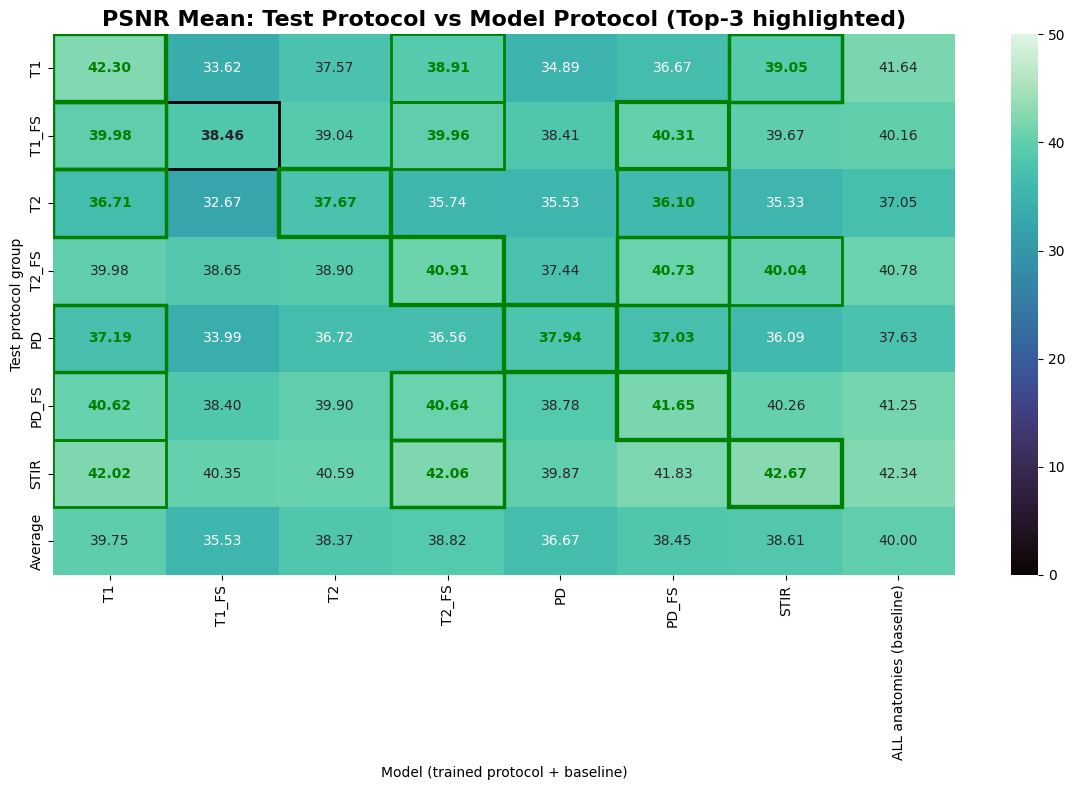

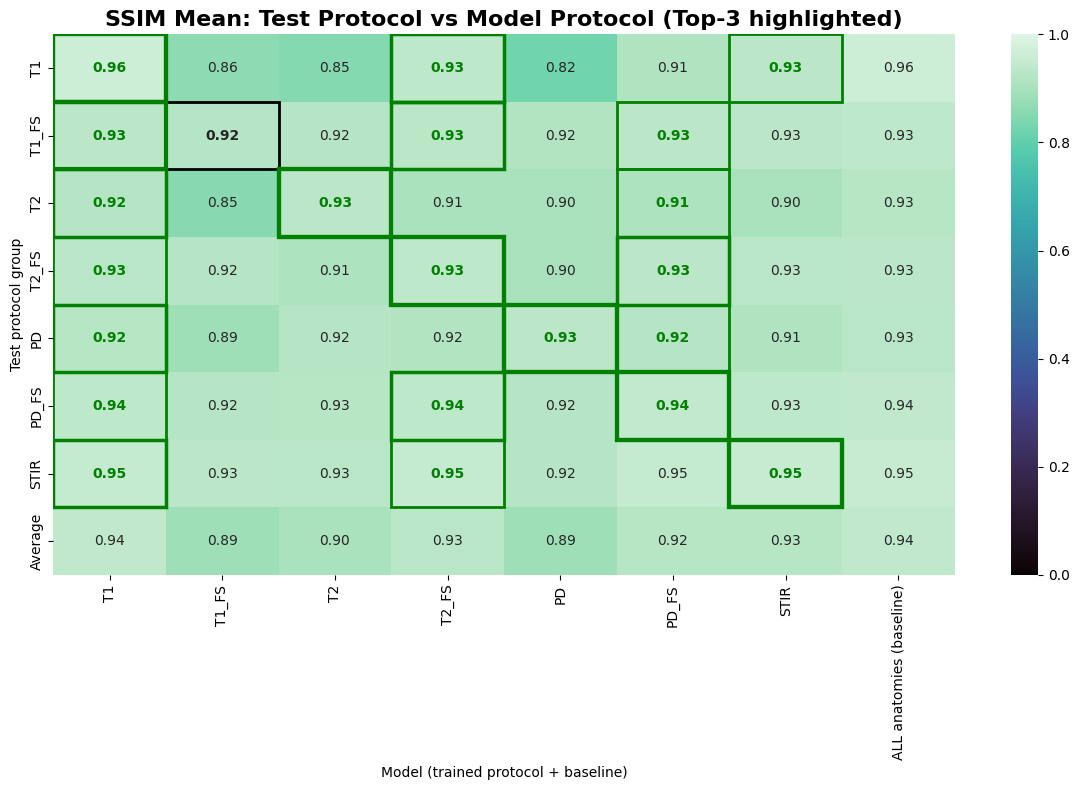


Diagonal PSNR margins (trained-on vs best other protocol model, excluding baseline):
protocol  PSNR_diag  PSNR_best_other  PSNR_margin
      T1  42.301591        39.045350     3.256241
   PD_FS  41.650109        40.642767     1.007342
      T2  37.666420        36.714507     0.951913
      PD  37.940936        37.185976     0.754960
    STIR  42.666463        42.056874     0.609589
   T2_FS  40.908781        40.727693     0.181089
   T1_FS  38.463794        40.311935    -1.848141

Average row PSNR values (global metrics):
model_protocol
T1                          39.753768
T1_FS                       35.530893
T2                          38.365560
T2_FS                       38.822441
PD                          36.666269
PD_FS                       38.445606
STIR                        38.610524
ALL anatomies (baseline)    40.003435
Name: Average, dtype: float64


In [ ]:
# Cross-protocol heatmaps: rows=test protocol (from header), cols=model (trained per protocol + baseline)
import re, json, os, numpy as np, h5py
try:
    import seaborn as sns
    _HAS_SEABORN = True
except ImportError:
    _HAS_SEABORN = False

# Define model result directories for each protocol-group trained model (adjust paths as needed)
protocol_groups = [
    "T1", 
    "T1_FS", 
    "T2", 
    "T2_FS", 
    "PD", 
    "PD_FS", 
    "STIR"
    ]
model_result_dirs = [
    f"../outputs/january_exps/protocols_full/test_on_msk/varnet_msk_protocols_{pg}_casc8_acc8" for pg in protocol_groups
]
baseline_dir = "../outputs/january_exps/test_on_msk/varnet_mskmrpro_FULL_casc8_acc8"
baseline_col_name = "ALL anatomies (baseline)"

# --- normalize model names found in metrics paths to protocol keys (T1, T2_FS, ...) ---
_model_pat = re.compile(r"varnet_msk_protocols_([^/_]+(?:_[^/_]+)?)", re.IGNORECASE)
def normalize_model_protocol(raw: str) -> str:
    """Map raw model_protocol strings/paths to canonical keys used in ordered_models."""
    if raw is None:
        return None
    s = str(raw).strip()
    m = _model_pat.search(s)
    if m:
        s = m.group(1)
    for suff in ("_CASC8_ACC8", "_CASC8", "_ACC8"):
        if s.upper().endswith(suff):
            s = s[: -len(suff)]
    s = s.upper().replace('-', '_')
    mapping = {
        'T1': 'T1',
        'T1_FS': 'T1_FS',
        'T2': 'T2',
        'T2_FS': 'T2_FS',
        'PD': 'PD',
        'PD_FS': 'PD_FS',
        'STIR': 'STIR',
    }
    return mapping.get(s, s)

# Robust extractor for global means with fallbacks to per_volume means if needed
def _extract_stat(x):
    if x is None:
        return None
    if isinstance(x, dict):
        for k in ("mean", "Mean", "MEAN", "avg", "average", "value"):
            if k in x:
                try:
                    return float(x[k])
                except Exception:
                    return None
        return None
    try:
        return float(x)
    except Exception:
        return None

def extract_global_means(metrics_json, per_vol):
    psnr_mean = None
    ssim_mean = None
    if isinstance(metrics_json, dict):
        glob = metrics_json.get('global') or metrics_json.get('Global') or {}
        if isinstance(glob, dict):
            psnr_mean = _extract_stat(glob.get('PSNR'))
            ssim_mean = _extract_stat(glob.get('SSIM'))
        if psnr_mean is None:
            psnr_mean = _extract_stat(metrics_json.get('PSNR'))
        if ssim_mean is None:
            ssim_mean = _extract_stat(metrics_json.get('SSIM'))
    if (psnr_mean is None or ssim_mean is None) and isinstance(per_vol, dict) and per_vol:
        ps = [v.get('PSNR') for v in per_vol.values() if v and v.get('PSNR') is not None]
        ss = [v.get('SSIM') for v in per_vol.values() if v and v.get('SSIM') is not None]
        if ps and psnr_mean is None:
            try:
                psnr_mean = float(np.nanmean(ps))
            except Exception:
                pass
        if ss and ssim_mean is None:
            try:
                ssim_mean = float(np.nanmean(ss))
            except Exception:
                pass
    print(f"Extracted global means: PSNR={psnr_mean}, SSIM={ssim_mean}")
    return psnr_mean, ssim_mean

header_data_dir = data_dir  # from earlier cell

all_rows = []
model_global_psnr = {}
model_global_ssim = {}
for model_dir in model_result_dirs:
    metrics_path = os.path.join(model_dir, 'metrics.json')
    model_proto = normalize_model_protocol(model_dir)
    if not os.path.exists(metrics_path):
        print(f"Missing metrics.json in {model_dir}, skipping")
        continue
    try:
        with open(metrics_path, 'r') as f:
            mj = json.load(f)
        per_vol_local = mj.get('per_volume', {})
        psnr_g, ssim_g = extract_global_means(mj, per_vol_local)
        model_global_psnr[model_proto] = psnr_g
        model_global_ssim[model_proto] = ssim_g
    except Exception as e:
        print(f"Error reading {metrics_path}: {e}")
        continue

    for fname, m in per_vol_local.items():
        h5_path = os.path.join(header_data_dir, fname)
        proto = parse_header_protocol(h5_path)
        test_group = get_contrast_group(proto)
        all_rows.append({
            'file': fname,
            'test_protocol': test_group,
            'model_protocol': model_proto,
            'PSNR': m.get('PSNR'),
            'SSIM': m.get('SSIM'),
        })

baseline_metrics_path = os.path.join(baseline_dir, 'metrics.json')
baseline_per_vol = {}
baseline_global_psnr = None
baseline_global_ssim = None
if os.path.exists(baseline_metrics_path):
    try:
        with open(baseline_metrics_path, 'r') as f:
            b_mj = json.load(f)
        baseline_per_vol = b_mj.get('per_volume', {})
        baseline_global_psnr, baseline_global_ssim = extract_global_means(b_mj, baseline_per_vol)
    except Exception as e:
        print(f"Error reading baseline metrics: {e}")
else:
    print("Baseline metrics.json not found; baseline column will be NaN.")

for fname, m in baseline_per_vol.items():
    h5_path = os.path.join(header_data_dir, fname)
    proto = parse_header_protocol(h5_path)
    test_group = get_contrast_group(proto)
    all_rows.append({
        'file': fname,
        'test_protocol': test_group,
        'model_protocol': baseline_col_name,
        'PSNR': m.get('PSNR'),
        'SSIM': m.get('SSIM'),
    })
model_global_psnr[baseline_col_name] = baseline_global_psnr
model_global_ssim[baseline_col_name] = baseline_global_ssim

cross_df = pd.DataFrame(all_rows)
print(f"Loaded {len(cross_df)} recon entries across {len(model_result_dirs)} models + baseline.")

valid_tests = cross_df.dropna(subset=['test_protocol']).copy()
valid_tests = valid_tests[valid_tests['test_protocol'].isin(protocol_groups)]

print("\nValid test_protocol counts:")
print(valid_tests['test_protocol'].value_counts(dropna=False))
print("\nValid model_protocol counts (top 15):")
print(valid_tests['model_protocol'].value_counts(dropna=False).head(15))
unknown_models = sorted(set(valid_tests['model_protocol']) - set(protocol_groups) - {baseline_col_name})
if unknown_models:
    print("\nModel protocols not in protocol_groups (check normalization):")
    print(unknown_models[:30])

ordered_tests = protocol_groups
ordered_models = protocol_groups + [baseline_col_name]

psnr_matrix = (
    valid_tests.groupby(['test_protocol','model_protocol'])['PSNR']
    .mean()
    .unstack('model_protocol')
    .reindex(index=ordered_tests, columns=ordered_models)
)
ssim_matrix = (
    valid_tests.groupby(['test_protocol','model_protocol'])['SSIM']
    .mean()
    .unstack('model_protocol')
    .reindex(index=ordered_tests, columns=ordered_models)
)

avg_psnr_row = [model_global_psnr.get(m) for m in ordered_models]
avg_ssim_row = [model_global_ssim.get(m) for m in ordered_models]
psnr_matrix.loc['Average'] = avg_psnr_row
ssim_matrix.loc['Average'] = avg_ssim_row

row_nan_counts = psnr_matrix.isna().sum(axis=1)
print("\nPSNR matrix NaN counts per row:")
print(row_nan_counts)
all_nan_rows = row_nan_counts[row_nan_counts >= psnr_matrix.shape[1]].index.tolist()
if all_nan_rows:
    print("Rows with ALL NaNs (no data for any model):", all_nan_rows)

def _topk_col_indices(row_values, cols_to_consider, k=3):
    """Return list of up to k column indices sorted best->worse, skipping NaNs."""
    vals = row_values[cols_to_consider]
    if np.all(np.isnan(vals)):
        return []
    finite_mask = ~np.isnan(vals)
    finite_idx_local = np.where(finite_mask)[0]
    finite_vals = vals[finite_mask]
    # sort descending by value
    order = np.argsort(-finite_vals)
    top_local = finite_idx_local[order][:k]
    return [cols_to_consider[int(i)] for i in top_local]

def plot_heatmap(matrix, title, cmap='mako', vmin=None, vmax=None, fmt=".2f", topk=3):
    plt.figure(figsize=(12, 8))
    data = matrix.values
    nrows, ncols = data.shape
    row_labels = list(matrix.index)
    col_labels = list(matrix.columns)
    try:
        baseline_j = col_labels.index(baseline_col_name)
    except ValueError:
        baseline_j = None
    cols_to_consider = [j for j in range(ncols) if j != baseline_j] if baseline_j is not None else list(range(ncols))

    # Precompute top-k per row (skip Average row)
    row_topk = []
    for i in range(nrows):
        if row_labels[i] == 'Average':
            row_topk.append([])
            continue
        row_topk.append(_topk_col_indices(data[i], cols_to_consider, k=topk))

    if _HAS_SEABORN:
        ax = sns.heatmap(matrix, annot=True, fmt=fmt, cmap=cmap, vmin=vmin, vmax=vmax, cbar=True)
    else:
        ax = plt.gca()
        im = ax.imshow(data, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
        plt.colorbar(im, ax=ax)
        for i in range(nrows):
            for j in range(ncols):
                val = data[i, j]
                if not np.isnan(val):
                    ax.text(j+0.5, i+0.5, f"{val:{fmt}}", ha='center', va='center', color='white', fontsize=9)
        ax.set_xticks(np.arange(ncols)+0.5)
        ax.set_xticklabels(matrix.columns, rotation=45, ha='right')
        ax.set_yticks(np.arange(nrows)+0.5)
        ax.set_yticklabels(matrix.index)

    # Highlight diagonal and top-k
    protocol_rows = [i for i, lbl in enumerate(row_labels) if lbl != 'Average']
    for i in protocol_rows:
        # diagonal emphasis
        if i < len(protocol_groups) and i < ncols:
            diag_is_in_topk = i in row_topk[i]
            diag_rect = plt.Rectangle((i, i), 1, 1, fill=False,
                                      edgecolor='green' if diag_is_in_topk else 'black',
                                      linewidth=3 if diag_is_in_topk else 2)
            ax.add_patch(diag_rect)
        # top-k rectangles (ranked thickness)
        top_cols = row_topk[i]
        for rank, j in enumerate(top_cols):
            lw = 3 if rank == 0 else (2.5 if rank == 1 else 2)
            rect = plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='green', linewidth=lw)
            ax.add_patch(rect)

    # Bold/green top-k text for seaborn annotations
    if _HAS_SEABORN:
        texts = ax.texts
        ncols_local = ncols
        for i in protocol_rows:
            for rank, j in enumerate(row_topk[i]):
                idx = i * ncols_local + j
                if 0 <= idx < len(texts):
                    texts[idx].set_color('green')
                    texts[idx].set_weight('bold')
            # If diagonal isn't topk but exists, still bold it for readability
            if i < len(protocol_groups):
                diag_idx = i * ncols_local + i
                if 0 <= diag_idx < len(texts):
                    texts[diag_idx].set_weight('bold')

    plt.title(title, fontsize=16, weight='bold')
    plt.xlabel('Model (trained protocol + baseline)')
    plt.ylabel('Test protocol group')
    plt.tight_layout()
    plt.show()

plot_heatmap(psnr_matrix, 'PSNR Mean: Test Protocol vs Model Protocol (Top-3 highlighted)', cmap='mako', vmin=0, vmax=50, topk=3)
plot_heatmap(ssim_matrix, 'SSIM Mean: Test Protocol vs Model Protocol (Top-3 highlighted)', cmap='mako', vmin=0, vmax=1, topk=3)

# Print diagonal PSNR margins (exclude baseline column and Average row)
diag_advantages = []
for grp in protocol_groups:
    if grp in psnr_matrix.index and grp in psnr_matrix.columns:
        diag_val = psnr_matrix.loc[grp, grp]
        off_vals = psnr_matrix.loc[grp, [c for c in ordered_models if c != grp]].dropna()
        off_vals = off_vals.drop(labels=[baseline_col_name]) if baseline_col_name in off_vals.index else off_vals
        if not np.isnan(diag_val) and len(off_vals):
            best_off = off_vals.max()
            diag_advantages.append({'protocol': grp, 'PSNR_diag': diag_val, 'PSNR_best_other': best_off, 'PSNR_margin': diag_val - best_off})
avg_df = pd.DataFrame(diag_advantages).sort_values('PSNR_margin', ascending=False)
print('\nDiagonal PSNR margins (trained-on vs best other protocol model, excluding baseline):')
print(avg_df.to_string(index=False))

print('\nAverage row PSNR values (global metrics):')
print(psnr_matrix.loc['Average'])

In [10]:
valid_tests

,file,test_protocol,model_protocol,PSNR,SSIM
0,meas_MID00016_FID118817_COR_T2.h5,T2,varnet_msk_protocols_T1,36.302799,0.927028
1,meas_MID00016_FID120712_COR_T2.h5,T2,varnet_msk_protocols_T1,33.450836,0.898721
2,meas_MID00017_FID118818_SAG_T2.h5,T2,varnet_msk_protocols_T1,37.811961,0.941793
3,meas_MID00018_FID118819_AXIAL_T2.h5,T2,varnet_msk_protocols_T1,33.671187,0.828667
4,meas_MID00018_FID125144_COR_PD_FS.h5,PD_FS,varnet_msk_protocols_T1,34.252616,0.847101
...,...,...,...,...,...
3195,meas_MID00605_FID124541_SAG_T2_FS.h5,T2_FS,ALL anatomies (baseline),41.604567,0.957131
3196,meas_MID00607_FID124543_COR_T2_FS.h5,T2_FS,ALL anatomies (baseline),40.988227,0.942729
3197,meas_MID00608_FID124544_COR_T1.h5,T1,ALL anatomies (baseline),46.905612,0.990474
3198,meas_MID00615_FID124551_OBLIQUE_SAG_T1_CUFF.h5,T1,ALL anatomies (baseline),54.587704,0.998285
